# Text Model Result Visualization

Compare text-only TF-IDF Logistic Regression, text-only IndoBERT, and the proposed behavioral XGBoost approach from `reports/modelling`.

In [8]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

## Load Report Files

In [9]:
def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "reports").exists():
            return candidate
    raise FileNotFoundError("Project root with pyproject.toml and reports/ not found.")


def load_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return json.loads(path.read_text(encoding="utf-8"))


def load_confusion_matrix(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path, index_col=0)


def save_figure(name: str) -> None:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(FIGURES_DIR / name, dpi=200, bbox_inches="tight")


ROOT = find_project_root()
REPORTS_DIR = ROOT / "reports"
TFIDF_DIR = REPORTS_DIR / "tfidf_baseline"
INDOBERT_DIR = REPORTS_DIR / "indobert"
MODELLING_DIR = REPORTS_DIR / "modelling"
FIGURES_DIR = REPORTS_DIR / "text_model_visualization" / "figures"

tfidf_metrics = load_json(TFIDF_DIR / "metrics.json")
indobert_metrics = load_json(INDOBERT_DIR / "metrics.json")
modelling_metrics = load_json(MODELLING_DIR / "review_model_metrics.json")
proposed_cv_metrics = modelling_metrics["review_level_cv"]["stratified_kfold"]["xgboost"]["mean"]
tfidf_cm = load_confusion_matrix(TFIDF_DIR / "confusion_matrix.csv")
indobert_cm = load_confusion_matrix(INDOBERT_DIR / "confusion_matrix.csv")
proposed_cm = load_confusion_matrix(MODELLING_DIR / "review_confusion_matrix.csv")
feature_importance_df = pd.read_csv(MODELLING_DIR / "feature_importance.csv")
product_scores_df = pd.read_csv(MODELLING_DIR / "product_suspicious_scores.csv")
top_products_df = pd.read_csv(MODELLING_DIR / "top_suspicious_products.csv")

if product_scores_df["item_id"].duplicated().any():
    raise ValueError("Duplicate item_id rows in product_suspicious_scores.csv")

print(f"Project root: {ROOT}")
print(f"Figure output: {FIGURES_DIR.relative_to(ROOT)}")
print(f"TF-IDF rows: {tfidf_metrics.get('n_total')} | IndoBERT rows: {indobert_metrics.get('n_total')}")
print(f"Proposed model rows: {sum(modelling_metrics['label_counts'].values())} | Products ranked: {len(product_scores_df)}")

Project root: C:\Users\lfaja\OneDrive\Documents\Researches\2026_FakeReviewDetection
Figure output: reports\text_model_visualization\figures
TF-IDF rows: 500 | IndoBERT rows: 500
Proposed model rows: 500 | Products ranked: 144


## Metric Comparison

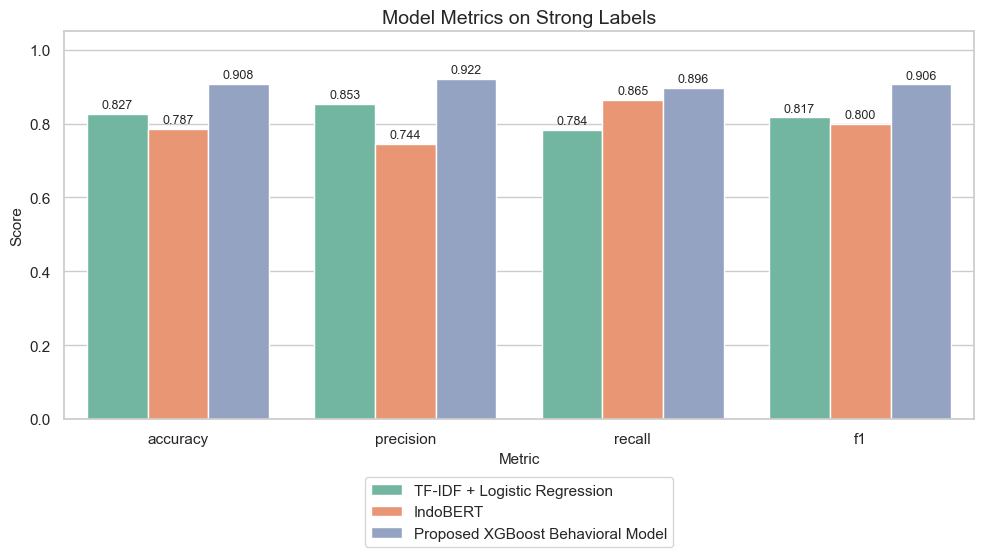

model,IndoBERT,Proposed XGBoost Behavioral Model,TF-IDF + Logistic Regression
metric,,,
accuracy,0.7867,0.9080,0.8267
f1,0.8000,0.9065,0.8169
precision,0.7442,0.9218,0.8529
recall,0.8649,0.8960,0.7838


,model,evaluation_basis
0,TF-IDF + Logistic Regression,75-row held-out text test split
1,IndoBERT,75-row held-out text test split
2,Proposed XGBoost Behavioral Model,500-row stratified OOF/CV behavioral evaluation


In [10]:
metric_names = ["accuracy", "precision", "recall", "f1"]
metrics_df = pd.DataFrame(
    [
        {
            "model": "TF-IDF + Logistic Regression",
            "metric": metric,
            "score": tfidf_metrics[metric],
            "evaluation_basis": "75-row held-out text test split",
        }
        for metric in metric_names
    ]
    + [
        {
            "model": "IndoBERT",
            "metric": metric,
            "score": indobert_metrics[metric],
            "evaluation_basis": "75-row held-out text test split",
        }
        for metric in metric_names
    ]
    + [
        {
            "model": "Proposed XGBoost Behavioral Model",
            "metric": metric,
            "score": proposed_cv_metrics[metric],
            "evaluation_basis": "500-row stratified OOF/CV behavioral evaluation",
        }
        for metric in metric_names
    ]
)
model_order = ["TF-IDF + Logistic Regression", "IndoBERT", "Proposed XGBoost Behavioral Model"]

ax = sns.barplot(data=metrics_df, x="metric", y="score", hue="model", hue_order=model_order, palette="Set2")
ax.set_title("Model Metrics on Strong Labels")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=9)
sns.move_legend(ax, "lower center", bbox_to_anchor=(0.5, -0.35), ncol=1, title=None)
plt.tight_layout()
save_figure("text_model_metric_comparison.png")
plt.show()

display(metrics_df.pivot(index="metric", columns="model", values="score").round(4))
metrics_df[["model", "evaluation_basis"]].drop_duplicates().reset_index(drop=True)

## Precision, Recall, and F1

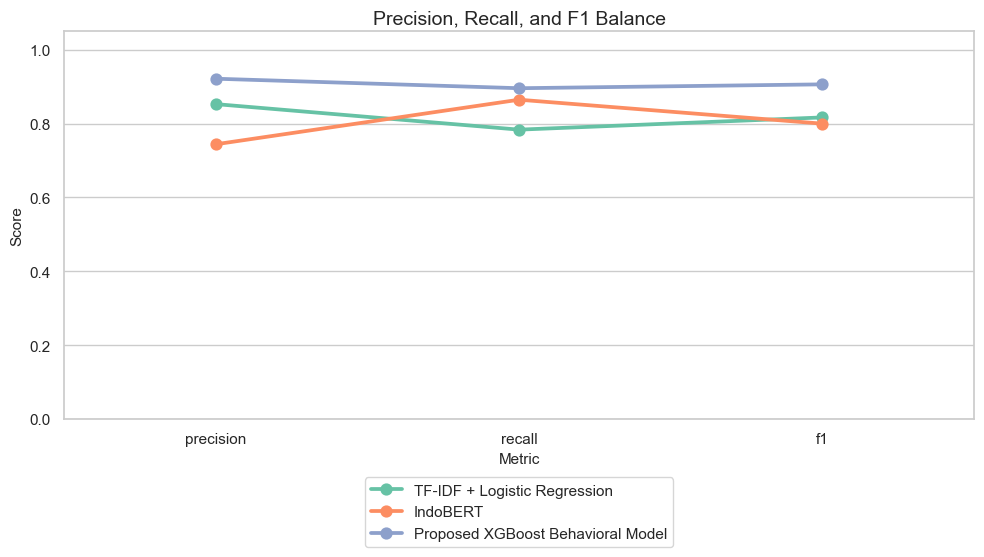

,model,metric,score,evaluation_basis
1,TF-IDF + Logistic Regression,precision,0.8529,75-row held-out text test split
2,TF-IDF + Logistic Regression,recall,0.7838,75-row held-out text test split
3,TF-IDF + Logistic Regression,f1,0.8169,75-row held-out text test split
5,IndoBERT,precision,0.7442,75-row held-out text test split
6,IndoBERT,recall,0.8649,75-row held-out text test split
7,IndoBERT,f1,0.8000,75-row held-out text test split
9,Proposed XGBoost Behavioral Model,precision,0.9218,500-row stratified OOF/CV behavioral evaluation
10,Proposed XGBoost Behavioral Model,recall,0.8960,500-row stratified OOF/CV behavioral evaluation
11,Proposed XGBoost Behavioral Model,f1,0.9065,500-row stratified OOF/CV behavioral evaluation


In [11]:
prf_df = metrics_df[metrics_df["metric"].isin(["precision", "recall", "f1"])].copy()

ax = sns.pointplot(data=prf_df, x="metric", y="score", hue="model", hue_order=model_order, palette="Set2", markers="o", linestyles="-")
ax.set_title("Precision, Recall, and F1 Balance")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
sns.move_legend(ax, "lower center", bbox_to_anchor=(0.5, -0.35), ncol=1, title=None)
plt.tight_layout()
save_figure("text_model_precision_recall_f1.png")
plt.show()

prf_df.round(4)

## Confusion Matrices

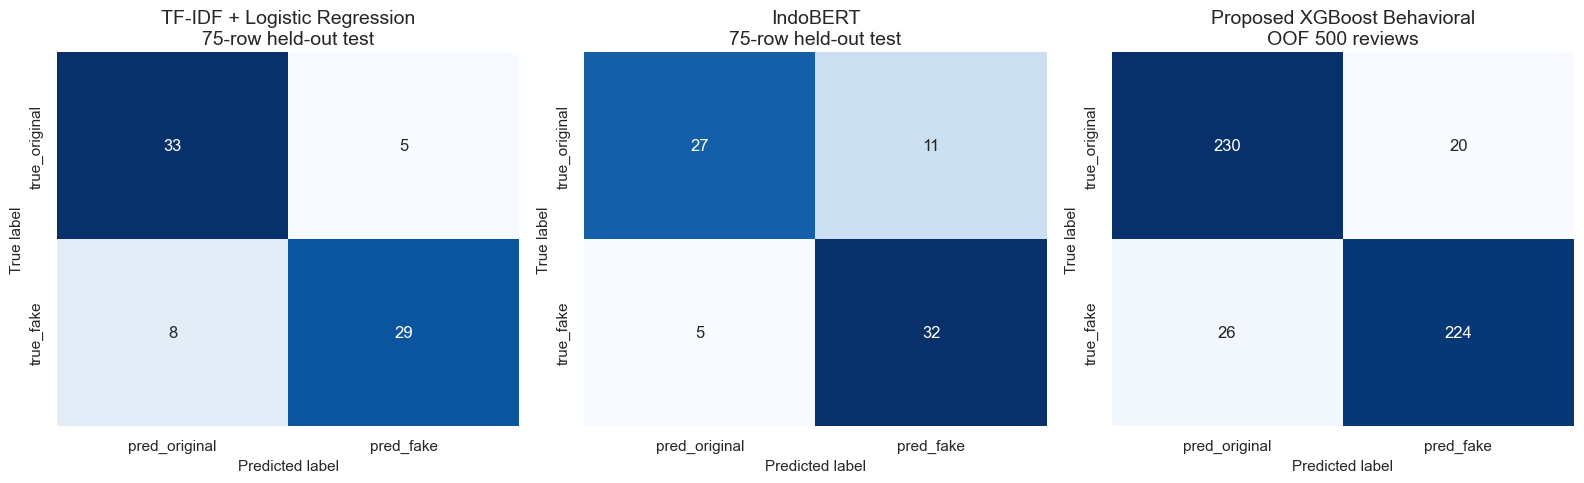

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, matrix, title in [
    (axes[0], tfidf_cm, "TF-IDF + Logistic Regression\n75-row held-out test"),
    (axes[1], indobert_cm, "IndoBERT\n75-row held-out test"),
    (axes[2], proposed_cm, "Proposed XGBoost Behavioral\nOOF 500 reviews"),
]:
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
plt.tight_layout()
save_figure("text_model_confusion_matrices.png")
plt.show()

## Train, Validation, and Test Label Counts

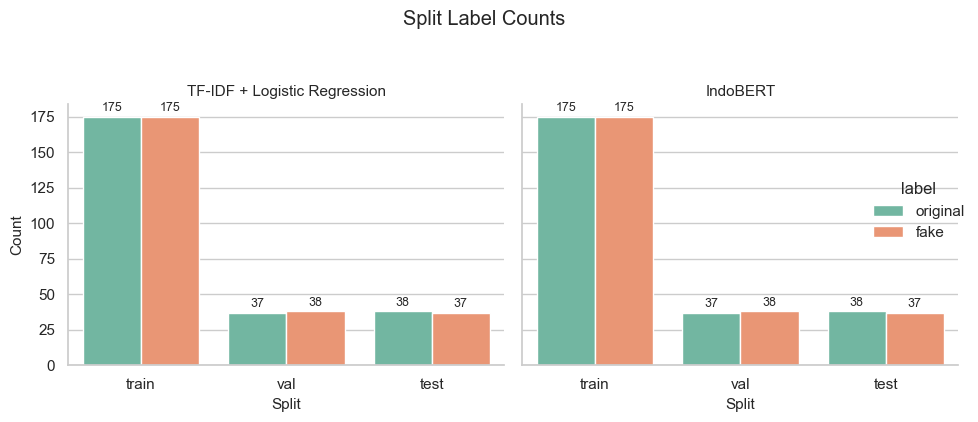

,model,split,label,count
0,TF-IDF + Logistic Regression,train,original,175
1,TF-IDF + Logistic Regression,train,fake,175
2,TF-IDF + Logistic Regression,val,original,37
3,TF-IDF + Logistic Regression,val,fake,38
4,TF-IDF + Logistic Regression,test,original,38
5,TF-IDF + Logistic Regression,test,fake,37
6,IndoBERT,train,original,175
7,IndoBERT,train,fake,175
8,IndoBERT,val,original,37
9,IndoBERT,val,fake,38


In [13]:
def split_count_rows(metrics: dict, model: str) -> list[dict]:
    rows = []
    for split, counts in metrics["split_label_counts"].items():
        for label, count in counts.items():
            rows.append({"model": model, "split": split, "label": label, "count": count})
    return rows


split_counts_df = pd.DataFrame(
    split_count_rows(tfidf_metrics, "TF-IDF + Logistic Regression")
    + split_count_rows(indobert_metrics, "IndoBERT")
)

g = sns.catplot(
    data=split_counts_df,
    x="split",
    y="count",
    hue="label",
    col="model",
    kind="bar",
    palette="Set2",
    height=4,
    aspect=1.1,
    order=["train", "val", "test"],
)
g.set_axis_labels("Split", "Count")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=2, fontsize=9)
g.figure.suptitle("Split Label Counts", y=1.05)
plt.tight_layout()
save_figure("text_model_split_label_counts.png")
plt.show()

split_counts_df

## Proposed Behavioral Model Outputs

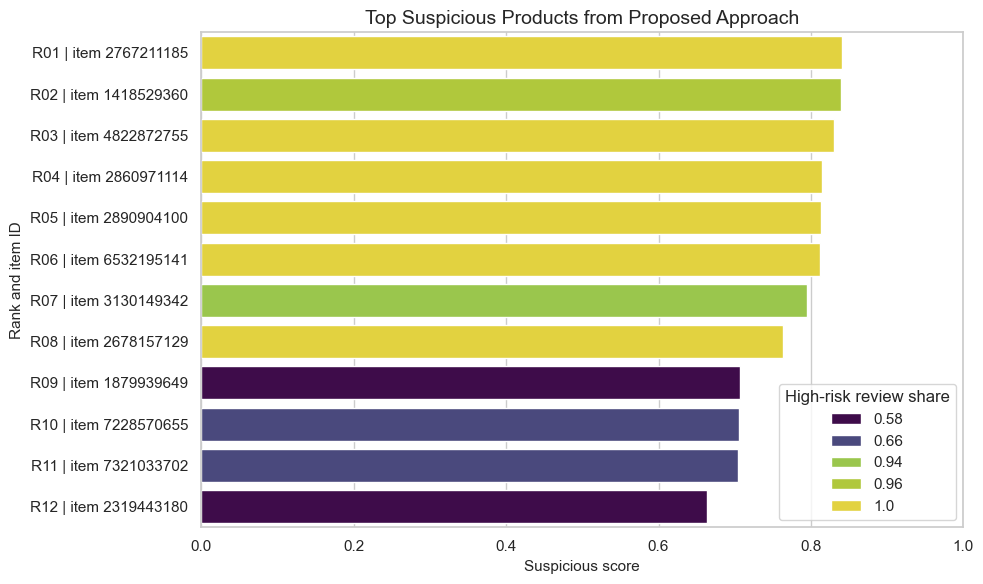

,rank,item_id,review_count,mean_fake_probability,high_risk_review_share,suspicious_score,reason_codes
0,1,2767211185,50,0.977687,1.00,0.8409,many high-risk reviews; high mean fake probabi...
1,2,1418529360,50,0.911532,0.96,0.8390,many high-risk reviews; duplicate comment patt...
2,3,4822872755,50,0.941964,1.00,0.8301,many high-risk reviews; high mean fake probabi...
3,4,2860971114,50,0.846131,1.00,0.8141,many high-risk reviews; high mean fake probabi...
4,5,2890904100,50,0.974621,1.00,0.8132,many high-risk reviews; high mean fake probabi...
5,6,6532195141,50,0.913649,1.00,0.8119,many high-risk reviews; high mean fake probabi...
6,7,3130149342,50,0.828206,0.94,0.7947,many high-risk reviews; high mean fake probabi...
7,8,2678157129,50,0.828593,1.00,0.7635,many high-risk reviews; high mean fake probabi...
8,9,1879939649,50,0.772438,0.58,0.7067,duplicate comment pattern; burst-like timing; ...
9,10,7228570655,50,0.725798,0.66,0.7056,duplicate comment pattern; high review volume;...


In [14]:
top_plot_df = top_products_df.head(12).copy()
top_plot_df["item_label"] = "R" + top_plot_df["rank"].astype(int).astype(str).str.zfill(2) + " | item " + top_plot_df["item_id"].astype(str)

ax = sns.barplot(
    data=top_plot_df,
    y="item_label",
    x="suspicious_score",
    hue="high_risk_review_share",
    palette="viridis",
    dodge=False,
)
ax.set_title("Top Suspicious Products from Proposed Approach")
ax.set_xlabel("Suspicious score")
ax.set_ylabel("Rank and item ID")
ax.set_xlim(0, max(1.0, top_plot_df["suspicious_score"].max() * 1.05))
sns.move_legend(ax, "lower right", title="High-risk review share")
plt.tight_layout()
save_figure("proposed_top_suspicious_products.png")
plt.show()

top_plot_df[["rank", "item_id", "review_count", "mean_fake_probability", "high_risk_review_share", "suspicious_score", "reason_codes"]]

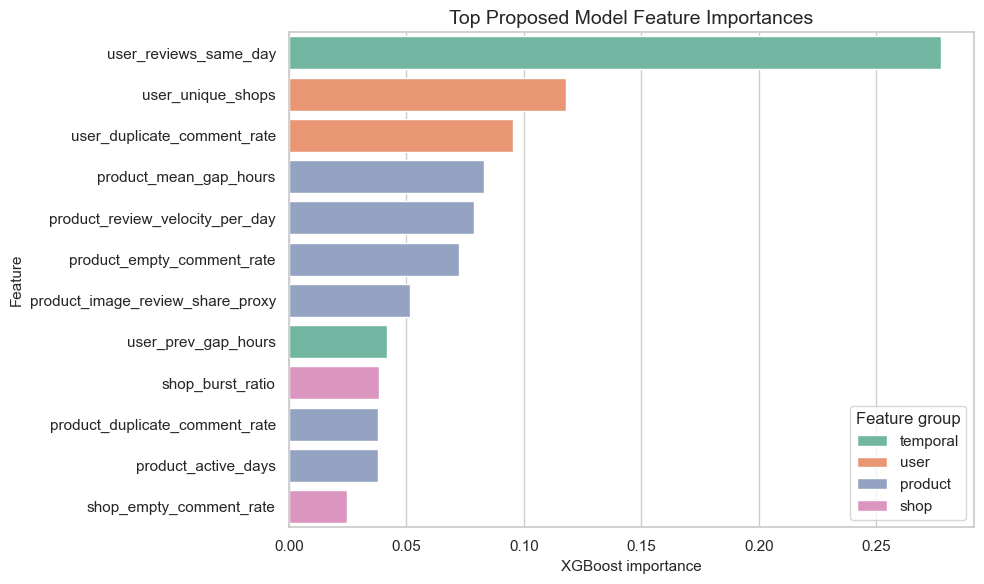

,feature,group,xgb_importance,permutation_importance_mean,consensus_rank
0,user_reviews_same_day,temporal,0.2777,0.0025,6
1,user_unique_shops,user,0.1178,0.0110,2
2,user_duplicate_comment_rate,user,0.0954,0.0087,1
3,product_mean_gap_hours,product,0.0829,0.0060,7
4,product_review_velocity_per_day,product,0.0787,0.0060,8
5,product_empty_comment_rate,product,0.0725,0.0001,14
6,product_image_review_share_proxy,product,0.0513,0.0043,12
7,user_prev_gap_hours,temporal,0.0417,-0.0005,11
8,shop_burst_ratio,shop,0.0383,0.0005,15
9,product_duplicate_comment_rate,product,0.0379,0.0014,3


In [15]:
feature_plot_df = feature_importance_df.sort_values("xgb_importance", ascending=False).head(12).copy()

ax = sns.barplot(
    data=feature_plot_df,
    y="feature",
    x="xgb_importance",
    hue="group",
    dodge=False,
    palette="Set2",
)
ax.set_title("Top Proposed Model Feature Importances")
ax.set_xlabel("XGBoost importance")
ax.set_ylabel("Feature")
sns.move_legend(ax, "lower right", title="Feature group")
plt.tight_layout()
save_figure("proposed_feature_importance.png")
plt.show()

feature_plot_df[["feature", "group", "xgb_importance", "permutation_importance_mean", "consensus_rank"]].round(4)

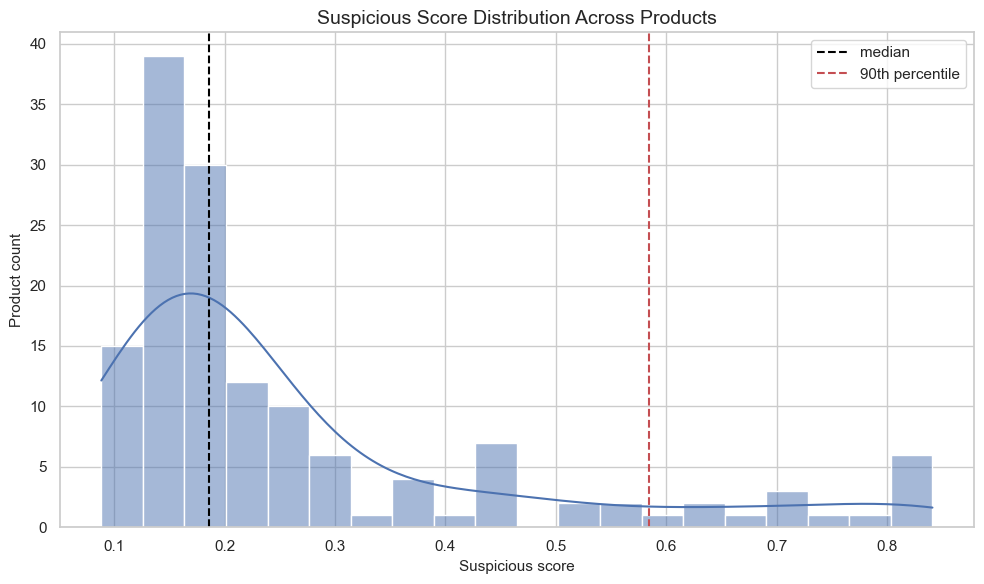

count    144.0000
mean       0.2671
std        0.1925
min        0.0884
25%        0.1478
50%        0.1861
75%        0.2922
max        0.8409
Name: suspicious_score, dtype: float64

In [16]:
ax = sns.histplot(data=product_scores_df, x="suspicious_score", bins=20, kde=True, color="#4C72B0")
ax.axvline(product_scores_df["suspicious_score"].median(), color="black", linestyle="--", label="median")
ax.axvline(product_scores_df["suspicious_score"].quantile(0.90), color="#C44E52", linestyle="--", label="90th percentile")
ax.set_title("Suspicious Score Distribution Across Products")
ax.set_xlabel("Suspicious score")
ax.set_ylabel("Product count")
ax.legend()
plt.tight_layout()
save_figure("proposed_suspicious_score_distribution.png")
plt.show()

product_scores_df["suspicious_score"].describe().round(4)

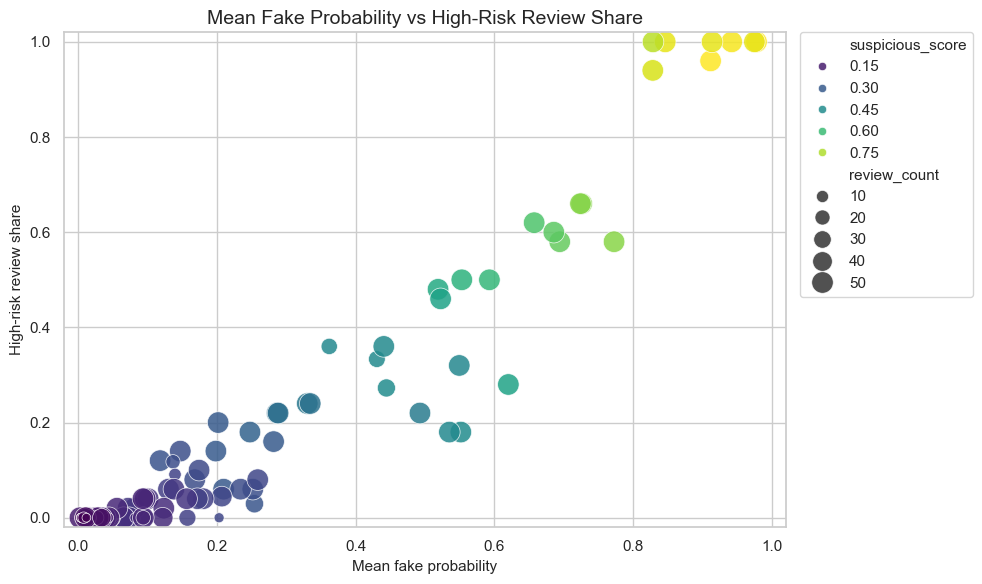

In [17]:
ax = sns.scatterplot(
    data=product_scores_df,
    x="mean_fake_probability",
    y="high_risk_review_share",
    size="review_count",
    hue="suspicious_score",
    palette="viridis",
    sizes=(40, 240),
    alpha=0.85,
)
ax.set_title("Mean Fake Probability vs High-Risk Review Share")
ax.set_xlabel("Mean fake probability")
ax.set_ylabel("High-risk review share")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
save_figure("proposed_probability_vs_high_risk_share.png")
plt.show()

## Summary Table

In [18]:
summary_df = pd.DataFrame(
    [
        {
            "model": "TF-IDF + Logistic Regression",
            "evaluation_basis": "75-row held-out text test split",
            "n_total": tfidf_metrics["n_total"],
            "n_train": tfidf_metrics["n_train"],
            "n_val": tfidf_metrics["n_val"],
            "n_test": tfidf_metrics["n_test"],
            "empty_text_count": tfidf_metrics["dataset"]["empty_text_count"],
            **{metric: tfidf_metrics[metric] for metric in metric_names},
        },
        {
            "model": "IndoBERT",
            "evaluation_basis": "75-row held-out text test split",
            "n_total": indobert_metrics["n_total"],
            "n_train": indobert_metrics["n_train"],
            "n_val": indobert_metrics["n_val"],
            "n_test": indobert_metrics["n_test"],
            "empty_text_count": indobert_metrics["dataset"]["empty_text_count"],
            **{metric: indobert_metrics[metric] for metric in metric_names},
        },
        {
            "model": "Proposed XGBoost Behavioral Model",
            "evaluation_basis": "500-row stratified OOF/CV behavioral evaluation",
            "n_total": sum(modelling_metrics["label_counts"].values()),
            "n_train": None,
            "n_val": None,
            "n_test": None,
            "empty_text_count": None,
            **{metric: proposed_cv_metrics[metric] for metric in metric_names},
        },
    ]
)

summary_df.round(4)

,model,evaluation_basis,n_total,n_train,n_val,n_test,empty_text_count,accuracy,precision,recall,f1
0,TF-IDF + Logistic Regression,75-row held-out text test split,500,350.0,75.0,75.0,15.0,0.8267,0.8529,0.7838,0.8169
1,IndoBERT,75-row held-out text test split,500,350.0,75.0,75.0,15.0,0.7867,0.7442,0.8649,0.8000
2,Proposed XGBoost Behavioral Model,500-row stratified OOF/CV behavioral evaluation,500,NaN,NaN,NaN,NaN,0.9080,0.9218,0.8960,0.9065
